In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import joblib
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load data dan model
df = pd.read_csv('../data/credit_clean.csv')
xgb_model = joblib.load('../models/xgboost_credit_risk.pkl')

# Recreate test set
cols_to_drop = ['TARGET']
optional_cols = ['INCOME_BRACKET', 'AGE_GROUP', 'CREDIT_INCOME_RATIO']
for col in optional_cols:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("All loaded successfully!")

All loaded successfully!


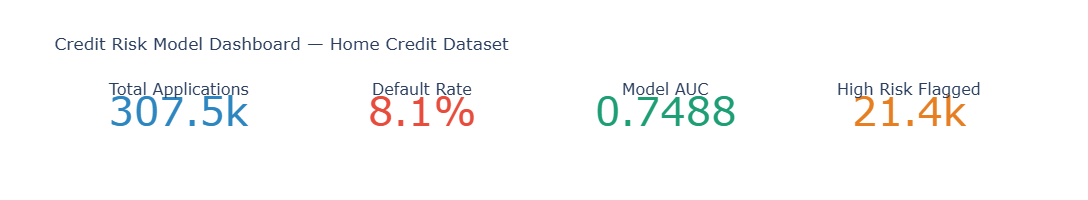

KPI cards created!


In [2]:
# Calculate KPI metrics
y_prob = xgb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_prob)
total_apps = len(df)
default_rate = df['TARGET'].mean()
high_risk = (y_prob > 0.5).sum()

fig_kpi = make_subplots(
    rows=1, cols=4,
    subplot_titles=('Total Applications', 'Default Rate',
                    'Model AUC', 'High Risk Flagged'),
    specs=[[{'type': 'indicator'}] * 4]
)

fig_kpi.add_trace(go.Indicator(
    mode='number',
    value=total_apps,
    number={'font': {'size': 40, 'color': '#2E86C1'}},
), row=1, col=1)

fig_kpi.add_trace(go.Indicator(
    mode='number',
    value=default_rate * 100,
    number={'suffix': '%', 'font': {'size': 40, 'color': '#E74C3C'},
            'valueformat': '.1f'},
), row=1, col=2)

fig_kpi.add_trace(go.Indicator(
    mode='number',
    value=auc_score,
    number={'font': {'size': 40, 'color': '#1D9E75'},
            'valueformat': '.4f'},
), row=1, col=3)

fig_kpi.add_trace(go.Indicator(
    mode='number',
    value=high_risk,
    number={'font': {'size': 40, 'color': '#E67E22'}},
), row=1, col=4)

fig_kpi.update_layout(
    title='Credit Risk Model Dashboard — Home Credit Dataset',
    height=200,
    paper_bgcolor='white'
)

fig_kpi.show()
print("KPI cards created!")

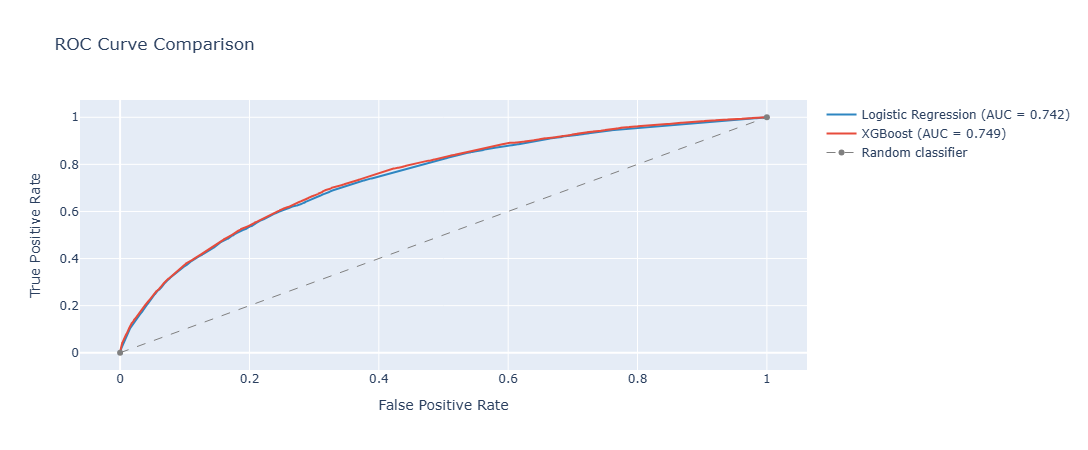

ROC curve created!


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Recreate all models for comparison
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = joblib.load('../models/scaler.pkl')
X_train_scaled = scaler.transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=42, max_iter=1000,
                               class_weight='balanced')
lr_model.fit(X_train_scaled, y_train_sm)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC curves
fig_roc = go.Figure()

models = {
    'Logistic Regression': (lr_prob, '#2E86C1'),
    'XGBoost': (y_prob, '#E74C3C')
}

for name, (prob, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    fig_roc.add_trace(go.Scatter(
        x=fpr, y=tpr,
        name=f'{name} (AUC = {auc:.3f})',
        line=dict(color=color, width=2)
    ))

fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    name='Random classifier',
    line=dict(color='gray', width=1, dash='dash')
))

fig_roc.update_layout(
    title='ROC Curve Comparison',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=450,
    paper_bgcolor='white'
)

fig_roc.show()
print("ROC curve created!")

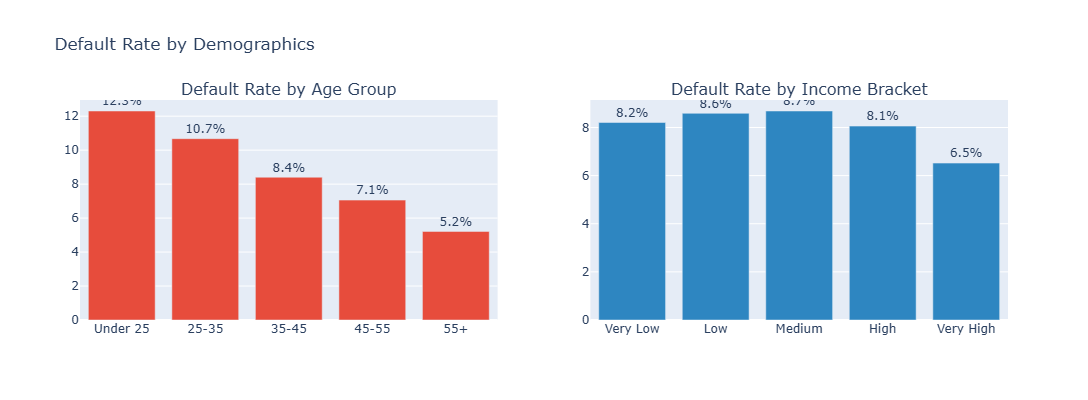

Demographics chart created!


In [4]:
fig_demo = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Default Rate by Age Group',
                    'Default Rate by Income Bracket')
)

# Age groups
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['Under 25', '25-35',
                                  '35-45', '45-55', '55+'])
age_default = df.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100

fig_demo.add_trace(go.Bar(
    x=age_default.index.astype(str),
    y=age_default.values,
    marker_color='#E74C3C',
    name='Age group',
    text=age_default.round(1).astype(str) + '%',
    textposition='outside'
), row=1, col=1)

# Income brackets
df['INCOME_BRACKET'] = pd.qcut(
    df['AMT_INCOME_TOTAL'], q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
income_default = df.groupby(
    'INCOME_BRACKET', observed=True)['TARGET'].mean() * 100

fig_demo.add_trace(go.Bar(
    x=income_default.index.astype(str),
    y=income_default.values,
    marker_color='#2E86C1',
    name='Income bracket',
    text=income_default.round(1).astype(str) + '%',
    textposition='outside'
), row=1, col=2)

fig_demo.update_layout(
    title='Default Rate by Demographics',
    height=400,
    showlegend=False,
    paper_bgcolor='white'
)

fig_demo.show()
print("Demographics chart created!")

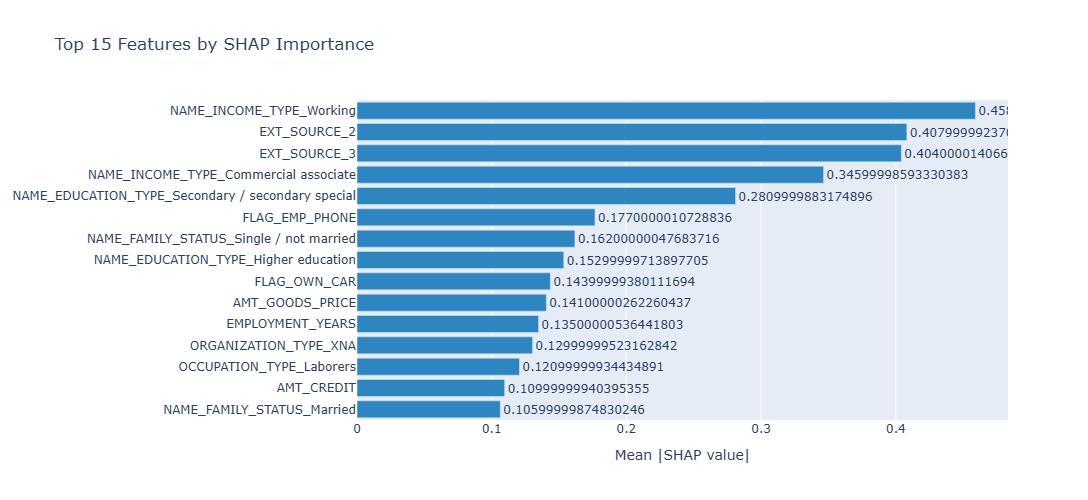

SHAP chart created!


In [5]:
# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Get mean absolute SHAP values
mean_shap = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=True).tail(15)

fig_shap = go.Figure(go.Bar(
    x=mean_shap['importance'],
    y=mean_shap['feature'],
    orientation='h',
    marker_color='#2E86C1',
    text=mean_shap['importance'].round(3),
    textposition='outside'
))

fig_shap.update_layout(
    title='Top 15 Features by SHAP Importance',
    xaxis_title='Mean |SHAP value|',
    height=500,
    paper_bgcolor='white'
)

fig_shap.show()
print("SHAP chart created!")

In [7]:
import os
os.makedirs('../dashboard', exist_ok=True)

from plotly.io import to_html

# Fix ROC curve layout
fig_roc.update_layout(height=500, width=900)

# Fix demographics layout  
fig_demo.update_layout(height=450, width=1200)

# Fix SHAP layout
fig_shap.update_layout(height=600, width=900)

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Credit Risk Analysis Dashboard</title>
    <style>
        body {{ font-family: Arial, sans-serif;
                background: #1a1a2e; padding: 30px; 
                color: white; }}
        h1 {{ color: #4FC3F7; text-align: center;
              font-size: 28px; margin-bottom: 5px; }}
        p {{ text-align: center; color: #aaa; 
             margin-bottom: 30px; }}
        .chart {{ background: white; border-radius: 12px;
                  padding: 15px; margin-bottom: 24px;
                  box-shadow: 0 4px 12px rgba(0,0,0,0.3); }}
        .chart-row {{ display: grid; 
                      grid-template-columns: 1fr 1fr;
                      gap: 24px; margin-bottom: 24px; }}
    </style>
</head>
<body>
    <h1>Credit Risk Analysis Dashboard</h1>
    <p>Home Credit Dataset · 307,511 loan applications · 
       XGBoost Model · AUC {auc_score:.4f} · 
       Built by M. Rijal Alghafiqih</p>

    <div class="chart">
        {to_html(fig_kpi, include_plotlyjs='cdn', full_html=False)}
    </div>

    <div class="chart-row">
        <div class="chart">
            {to_html(fig_roc, include_plotlyjs=False, full_html=False)}
        </div>
        <div class="chart">
            {to_html(fig_shap, include_plotlyjs=False, full_html=False)}
        </div>
    </div>

    <div class="chart">
        {to_html(fig_demo, include_plotlyjs=False, full_html=False)}
    </div>
</body>
</html>
"""

with open('../dashboard/credit_risk_dashboard.html', 'w') as f:
    f.write(html_content)

print("Dashboard exported!")
print("Open dashboard/credit_risk_dashboard.html in your browser!")

Dashboard exported!
Open dashboard/credit_risk_dashboard.html in your browser!
